In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn import linear_model
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
df1=pd.read_csv(r"gender_submission.csv")
test_data= pd.read_csv("test.csv")
X= pd.read_csv(r"train.csv")

In [3]:
X.shape

(891, 12)

In [4]:
X.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
X.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
X['Sex'] = X['Sex'].map({'male':0,'female':1})
X['Embarked'] = X['Embarked'].map({'S':0,'C':1,'Q':2})

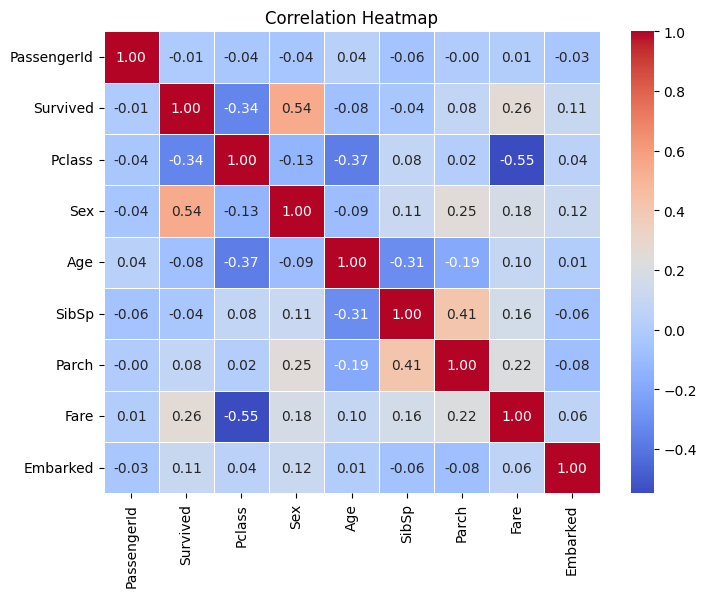

In [7]:
matrix_corr = X.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(matrix_corr, annot=True, cmap='coolwarm',fmt=".2f",linewidth=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [8]:
pd.crosstab(X['Survived'],X['Fare'])

Fare,0.0000,4.0125,5.0000,6.2375,6.4375,6.4500,6.4958,6.7500,6.8583,6.9500,...,153.4625,164.8667,211.3375,211.5000,221.7792,227.5250,247.5208,262.3750,263.0000,512.3292
Survived,,,,,,,,,,,,,,,,,,,,,
0,14,1,1,1,1,1,2,2,1,1,...,1,0,0,1,1,1,1,0,2,0
1,1,0,0,0,0,0,0,0,0,0,...,2,2,3,0,0,3,1,2,2,3


In [9]:
X.isna().sum()/len(X)*100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

In [10]:
y= X['Survived']
X= X.drop('Survived',axis=1)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)

In [12]:
imp_median =SimpleImputer(strategy='median')
X_train['Age'] = imp_median.fit_transform(X_train[['Age']])
X_test['Age']= imp_median.transform(X_test[['Age']])
X_train['Embarked'] = imp_median.fit_transform(X_train[['Embarked']])
X_test['Embarked'] = imp_median.transform(X_test[['Embarked']])

In [13]:
scaler=StandardScaler()
numeric_cols = X_train.select_dtypes(include='number').columns.tolist()
X_train[numeric_cols]= scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols]= scaler.transform(X_test[numeric_cols])


In [14]:
logisticr =linear_model.LogisticRegression(penalty='l2',C=1.0,max_iter=1000)
logisticr.fit(X_train[numeric_cols],y_train)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass`

In [15]:
predicted = logisticr.predict(X_test[numeric_cols])

In [16]:
print("Accuracy:\n",accuracy_score(y_test,predicted))
print("Confusion Matrix:\n")
print(confusion_matrix(y_test,predicted))
print("Classification Report:\n")
print(classification_report(y_test,predicted))

Accuracy:
 0.7988826815642458
Confusion Matrix:

[[89 16]
 [20 54]]
Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.85      0.83       105
           1       0.77      0.73      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



In [17]:
X_train

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
331,-0.453066,-1.614136,"Partner, Mr. Austen",-0.724310,1.253641,-0.470722,-0.479342,113043,-0.078684,C124,-0.548035
733,1.113874,-0.400551,"Berriman, Mr. William John",-0.724310,-0.477284,-0.470722,-0.479342,28425,-0.377145,NaN,-0.548035
382,-0.254275,0.813034,"Tikkanen, Mr. Juho",-0.724310,0.215086,-0.470722,-0.479342,STON/O 2. 3101293,-0.474867,NaN,-0.548035
704,1.000836,0.813034,"Hansen, Mr. Henrik Juul",-0.724310,-0.246494,0.379923,-0.479342,350025,-0.476230,NaN,-0.548035
813,1.425702,0.813034,"Andersson, Miss. Ebba Iris Alfrida",1.380624,-1.785093,2.931860,2.048742,347082,-0.025249,NaN,-0.548035
...,...,...,...,...,...,...,...,...,...,...,...
106,-1.330084,0.813034,"Salkjelsvik, Miss. Anna Kristine",1.380624,-0.631144,-0.470722,-0.479342,343120,-0.480162,NaN,-0.548035
270,-0.690835,-1.614136,"Cairns, Mr. Alexander",-0.724310,-0.092634,-0.470722,-0.479342,113798,-0.030545,NaN,-0.548035
860,1.608902,0.813034,"Hansen, Mr. Claus Peter",-0.724310,0.907456,1.230569,-0.479342,350026,-0.355804,NaN,-0.548035
435,-0.047689,-1.614136,"Carter, Miss. Lucile Polk",1.380624,-1.169653,0.379923,2.048742,113760,1.683201,B96 B98,-0.548035


In [18]:
print("Train:", logisticr.score(X_train[numeric_cols], y_train))
print("Test:", logisticr.score(X_test[numeric_cols], y_test))

Train: 0.8047752808988764
Test: 0.7988826815642458
